### Setting Up The System

In [1]:
# Changing the version in colab
!python3 --version
!sudo apt-get install python3.8

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.8 1

# Choose one of the given alternatives:
!sudo update-alternatives --config python3

!python3 --version

Python 3.8.10


Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


Python 3.8.10


### IMPORTING IMPORTANT LIBRARIES

In [33]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !c:\users\ajay\documents\sana\env\scripts\python.exe -m pip install --upgrade pip
# !pip install torch
# !pip install torchvision
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install scikit-learn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.6 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.3 MB 1.6 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.3 MB 1.5 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.3 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.4/9.3 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.3 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.3 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.3 MB 1.8 MB/s eta 0:00:04
   ------------------ --------------------- 4.2/9.3 MB 1.9 MB/s eta 0:00:03
   -------------------- ---------


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# torch.__version__
from torchvision import datasets, transforms, models  # datsets  , transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

In [2]:
torch.cuda.empty_cache()
!python3 --version

Python 3.8.10


### Import Dataset

<b> Dataset Link (Plant Vliiage Dataset ):</b><br> <a href='https://data.mendeley.com/datasets/tywbtsjrjv/1'> https://data.mendeley.com/datasets/tywbtsjrjv/1 </a>

In [4]:
transform = transforms.Compose(
    [transforms.Resize(255), transforms.CenterCrop(224), transforms.ToTensor()]
)

In [5]:
# The the link to where you have stored the dataset.
dataset = datasets.ImageFolder("../All_Datasets/Plant_leaf_diseases_dataset_with_augmentation/Plant_leave_diseases_dataset_with_augmentation", transform=transform)

In [6]:
dataset

Dataset ImageFolder
    Number of datapoints: 61486
    Root location: ../All_Datasets/Plant_leaf_diseases_dataset_with_augmentation/Plant_leave_diseases_dataset_with_augmentation
    StandardTransform
Transform: Compose(
               Resize(size=255, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
           )

In [7]:
indices = list(range(len(dataset)))

In [8]:
split = int(np.floor(0.85 * len(dataset)))  # train_size

In [9]:
validation = int(np.floor(0.70 * split))  # validation

In [10]:
print(0, validation, split, len(dataset))

0 36584 52263 61486


In [11]:
print(f"length of train size :{validation}")
print(f"length of validation size :{split - validation}")
print(f"length of test size :{len(dataset)-validation}")

length of train size :36584
length of validation size :15679
length of test size :24902


In [12]:
np.random.shuffle(indices)

### Split into Train and Test

In [13]:
train_indices, validation_indices, test_indices = (
    indices[:validation],
    indices[validation:split],
    indices[split:],
)

In [14]:
train_sampler = SubsetRandomSampler(train_indices)
validation_sampler = SubsetRandomSampler(validation_indices)
test_sampler = SubsetRandomSampler(test_indices)

In [15]:
targets_size = len(dataset.class_to_idx)
print(targets_size)

39


### Model

<b>Convolution Aithmetic Equation : </b>(W - F + 2P) / S + 1 <br>
W = Input Size<br>
F = Filter Size<br>
P = Padding Size<br>
S = Stride <br>

### Original Modeling

In [16]:
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # conv1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            # conv2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            # conv3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            # conv4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )

    def forward(self, X):
        out = self.conv_layers(X)

        # Flatten
        out = out.view(-1, 50176)

        # Fully connected
        out = self.dense_layers(out)

        return out

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
print(device) # = "cpu"

cuda


In [19]:
model = CNN(targets_size).to(device)

In [20]:
model.to(device)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [21]:
# !pip install torchsummary
from torchsummary import summary

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
       BatchNorm2d-3         [-1, 32, 224, 224]              64
            Conv2d-4         [-1, 32, 224, 224]           9,248
              ReLU-5         [-1, 32, 224, 224]               0
       BatchNorm2d-6         [-1, 32, 224, 224]              64
         MaxPool2d-7         [-1, 32, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          18,496
              ReLU-9         [-1, 64, 112, 112]               0
      BatchNorm2d-10         [-1, 64, 112, 112]             128
           Conv2d-11         [-1, 64, 112, 112]          36,928
             ReLU-12         [-1, 64, 112, 112]               0
      BatchNorm2d-13         [-1, 64, 112, 112]             128
        MaxPool2d-14           [-1, 64,

In [22]:
criterion = nn.CrossEntropyLoss()  # this include softmax + cross entropy loss
optimizer = torch.optim.Adam(model.parameters())

### Batch Gradient Descent

In [23]:
def batch_gd(model, criterion, train_loader, test_laoder, epochs):
    train_losses = np.zeros(epochs)
    validation_losses = np.zeros(epochs)

    for e in range(epochs):
        t0 = datetime.now()
        train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()

            output = model(inputs)

            loss = criterion(output, targets)

            train_loss.append(loss.item())  # torch to numpy world

            loss.backward()
            optimizer.step()

        train_loss = np.mean(train_loss)

        validation_loss = []

        for inputs, targets in validation_loader:

            inputs, targets = inputs.to(device), targets.to(device)

            output = model(inputs)

            loss = criterion(output, targets)

            validation_loss.append(loss.item())  # torch to numpy world

        validation_loss = np.mean(validation_loss)

        train_losses[e] = train_loss
        validation_losses[e] = validation_loss

        dt = datetime.now() - t0

        print(
            f"Epoch : {e+1}/{epochs} Train_loss:{train_loss:.3f} Test_loss:{validation_loss:.3f} Duration:{dt}"
        )

    return train_losses, validation_losses

In [24]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=train_sampler, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=test_sampler, num_workers=2, pin_memory=True
)
validation_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, sampler=validation_sampler, num_workers=2, pin_memory=True
)

In [25]:
# # print(model)
train_losses, validation_losses = batch_gd(
    model, criterion, train_loader, validation_loader, 5
)

# torch.cuda.empty_cache()


Epoch : 1/5 Train_loss:2.609 Test_loss:2.126 Duration:0:08:37.946075
Epoch : 2/5 Train_loss:1.705 Test_loss:1.588 Duration:0:12:17.200856
Epoch : 3/5 Train_loss:1.400 Test_loss:1.259 Duration:0:14:17.847976
Epoch : 4/5 Train_loss:1.089 Test_loss:1.020 Duration:0:14:18.444324
Epoch : 5/5 Train_loss:0.901 Test_loss:0.938 Duration:0:14:20.280542


### Save the Model

In [26]:
torch.save(model.state_dict() , 'pdd-D02-original.pt')

### Load Model

In [27]:
targets_size = 39
print(device)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# Initialize the model
model = CNN(targets_size)

# Load the state dictionary
model.load_state_dict(torch.load("pdd-D02-original.pt", map_location=device))

# Move the entire model to the correct device
model = model.to(device)

# Verify the device of each parameter
model.eval()
for name, param in model.named_parameters():
    print(f"{name} is on {param.device}")


cuda
cuda


C:\Users\AJAY\AppData\Local\Temp\ipykernel_10436\550403199.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("pdd-D02-original.pt", map_l

conv_layers.0.weight is on cuda:0
conv_layers.0.bias is on cuda:0
conv_layers.2.weight is on cuda:0
conv_layers.2.bias is on cuda:0
conv_layers.3.weight is on cuda:0
conv_layers.3.bias is on cuda:0
conv_layers.5.weight is on cuda:0
conv_layers.5.bias is on cuda:0
conv_layers.7.weight is on cuda:0
conv_layers.7.bias is on cuda:0
conv_layers.9.weight is on cuda:0
conv_layers.9.bias is on cuda:0
conv_layers.10.weight is on cuda:0
conv_layers.10.bias is on cuda:0
conv_layers.12.weight is on cuda:0
conv_layers.12.bias is on cuda:0
conv_layers.14.weight is on cuda:0
conv_layers.14.bias is on cuda:0
conv_layers.16.weight is on cuda:0
conv_layers.16.bias is on cuda:0
conv_layers.17.weight is on cuda:0
conv_layers.17.bias is on cuda:0
conv_layers.19.weight is on cuda:0
conv_layers.19.bias is on cuda:0
conv_layers.21.weight is on cuda:0
conv_layers.21.bias is on cuda:0
conv_layers.23.weight is on cuda:0
conv_layers.23.bias is on cuda:0
conv_layers.24.weight is on cuda:0
conv_layers.24.bias is on

In [ ]:
# %matplotlib notebook

### Plot the loss

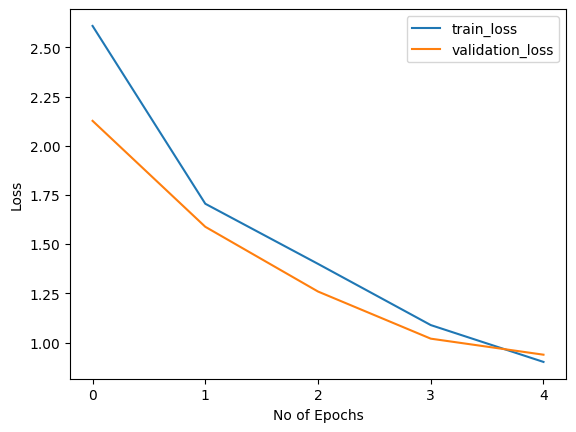

In [28]:
plt.plot(train_losses , label = 'train_loss')
plt.plot(validation_losses , label = 'validation_loss')
plt.xticks(range(0,5))
plt.xlabel('No of Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Accuracy

In [29]:
print(device)

def accuracy(loader):
    n_correct = 0
    n_total = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)

        _, predictions = torch.max(outputs, 1)

        n_correct += (predictions == targets).sum().item()
        n_total += targets.shape[0]

    acc = n_correct / n_total
    return acc

cuda


In [30]:
train_acc = accuracy(train_loader)
test_acc = accuracy(test_loader)
validation_acc = accuracy(validation_loader)

In [35]:
print(
    f"Train Accuracy : {train_acc}\nTest Accuracy : {test_acc}\nValidation Accuracy : {validation_acc}"
)

Train Accuracy : 0.8712825278810409
Test Accuracy : 0.8423506451263146
Validation Accuracy : 0.8374896358186109


In [34]:
from sklearn.metrics import classification_report

def evaluate_metrics(loader):
    y_true = []
    y_pred = []

    with torch.no_grad():  # No gradients needed during evaluation
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)  # Get class with max probability
            
            y_true.extend(targets.cpu().numpy())  # Store actual labels
            y_pred.extend(predictions.cpu().numpy())  # Store predicted labels

    # Compute precision, recall, and F1-score
    report = classification_report(y_true, y_pred, target_names=dataset.classes)
    return report

# Calculate and print metrics
print("Train Metrics:\n", evaluate_metrics(train_loader))
print("Validation Metrics:\n", evaluate_metrics(validation_loader))
print("Test Metrics:\n", evaluate_metrics(test_loader))


Train Metrics:
                                                precision    recall  f1-score   support

                           Apple___Apple_scab       0.78      0.63      0.70       558
                            Apple___Black_rot       0.86      0.83      0.85       575
                     Apple___Cedar_apple_rust       0.87      0.82      0.85       581
                              Apple___healthy       0.81      0.85      0.83       989
                    Background_without_leaves       0.85      0.98      0.91       680
                          Blueberry___healthy       0.93      0.93      0.93       897
                      Cherry___Powdery_mildew       0.88      0.86      0.87       636
                             Cherry___healthy       0.78      0.93      0.85       602
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.69      0.72       593
                           Corn___Common_rust       0.99      0.98      0.99       680
                  Corn___N